# First print your name in the cell below then save this file. (or something nice about your instructor)

In [2]:
# In this cell print your name 
print("Mubasshir Al Shahriar")


Mubasshir Al Shahriar


# Data wrangling with Pandas exercise
* For this exercise we will be using the `listings.csv` data file.

In [1]:
import pandas as pd
import numpy as np

# Load in the data file using `pd.read_csv()`

In [36]:
# Load data here
df = pd.read_csv("../data/listings.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,175,3,48,2019-11-04,0.37,2,365
1,3831,"Whole flr w/private bdrm, bath & kitchen(pls r...",4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,75,1,340,2020-08-01,4.75,1,265
2,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,29,50,2019-12-02,0.37,1,365
3,5136,"Spacious Brooklyn Duplex, Patio + Garden",7378,Rebecca,Brooklyn,Sunset Park,40.66120,-73.99423,Entire home/apt,175,14,1,2014-01-02,0.01,1,295
4,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,65,2,473,2020-03-15,3.44,1,340


## Exercise 2 - Filtering

Return the following subsets of the dataframe.

1. How many listings are there with a price less than 100? 


2. Find how many listings there are in just Brooklyn.


3. Find how many listings there are in Brooklyn with a price less than 100.


4. Using `.isin()` select anyone that has the host name of Michael, David, John, and Daniel.


5. Create a new column called `adjusted_price` that has $100 added to every listing in Williamsburg.  The prices for all other listings should be the same as the were before. 


6. What % of the rooms are private, and what % of the rooms are shared.  
    * Hint, use `.value_counts()`


In [11]:
# 1. How many listings are there with a price less than 100? 

df[df["price"] < 100].shape[0]


22778

In [15]:
# 2. Make a new DataFrame of listings in Brooklyn named `df_bk` 
# and find how many listings in just Brooklyn.

df_bk = df[df["neighbourhood_group"] == "Brooklyn"]
df_bk.shape[0]

18632

In [16]:
# 3. Find how many listings there are in Brooklyn with a price less than 100.

df_bk[df_bk["price"] < 100].shape[0]


10473

In [3]:
# 4. Using `.isin()` select anyone that has the host name of Michael, David, John, and Daniel.
# How many total are there that have those names

df_names = df[df["host_name"].isin(["Michael", "David", "John", "Daniel"])]
df_names.shape[0]

1258

In [19]:
# 5. Create a new column called `adjusted_price` that has $100 added to every listing in Williamsburg.  
# The prices for all other listings should be the same as the were before. 

def my_function(x):
    if x["neighbourhood"] == "Williamsburg":
        return x["price"] + 100
    else:
        return x["price"]


df["adjusted_price"] = df.apply(my_function, axis=1)
df["adjusted_price"]


0        175
1         75
2         60
3        175
4         65
        ... 
46522    145
46523     87
46524     59
46525     80
46526     66
Name: adjusted_price, Length: 46527, dtype: int64

In [6]:
# 6. What % of the rooms are private, and what % of the rooms are shared.  

room_counts = df["room_type"].value_counts()
room_counts

room_percent = room_counts / len(df) * 100
room_percent

print("Private room: ", room_percent["Private room"])
print("Shared room: ", room_percent["Shared room"])


Private room:  45.444580566122895
Shared room:  2.12134889419047


# Exercise 3 - Grouping

1. Using `groupby`, count how many listings are in each neighbourhood_group.


2. Using `groupby`, find the mean price for each of the neighbourhood_groups. 


3. Using `groupby` and `.agg()`, find the min and max price for each of the neighbourhood_groups. 


4. Using `groupby`, find the median price for each room type in each neighbourhood_group.


5. Using `groupby` and `.agg()`, find the count, min, max, mean, median, and std of the prices for each room type in each neighbourhood_group.

In [12]:
# 1. Using `groupby`, count how many listings are in each neighbourhood_group.
df.groupby("neighbourhood_group").size()



neighbourhood_group
Bronx             1183
Brooklyn         18632
Manhattan        20580
Queens            5791
Staten Island      341
dtype: int64

In [13]:
# 2. Using `groupby`, find the mean price for each of the neighbourhood_groups. 

df.groupby("neighbourhood_group")["price"].mean()


neighbourhood_group
Bronx             92.751479
Brooklyn         120.225258
Manhattan        191.880466
Queens            99.754965
Staten Island    110.947214
Name: price, dtype: float64

In [17]:
# 2.5. Using `groupby`, find the mean price for each room_type. 
df.groupby("room_type")["price"].mean()

room_type
Entire home/apt    199.395950
Hotel room         275.015075
Private room        91.453084
Shared room         87.063830
Name: price, dtype: float64

In [18]:
# 3. Using `groupby` and `.agg()`, find the min and max price for each of the neighbourhood_groups. 
df.groupby("neighbourhood_group")["price"].agg(["min", "max"])



,min,max
neighbourhood_group,,
Bronx,16,1404
Brooklyn,0,10000
Manhattan,0,10000
Queens,0,10000
Staten Island,19,1200


In [19]:
# 4. Using `groupby`, find the mean price for each room_type in each neighbourhood_group.

df.groupby(["neighbourhood_group", "room_type"])["price"].median()

neighbourhood_group  room_type      
Bronx                Entire home/apt    103.0
                     Private room        55.0
                     Shared room         44.0
Brooklyn             Entire home/apt    135.0
                     Hotel room         129.0
                     Private room        60.0
                     Shared room         36.0
Manhattan            Entire home/apt    165.0
                     Hotel room         210.0
                     Private room        80.0
                     Shared room         60.0
Queens               Entire home/apt    115.0
                     Hotel room         149.0
                     Private room        55.0
                     Shared room         40.0
Staten Island        Entire home/apt    111.0
                     Private room        55.0
                     Shared room         38.0
Name: price, dtype: float64

In [20]:
# 5. Using `groupby` and `.agg()`, find the count, min, max, mean, median, and std of the prices 
# for each room type in each neighbourhood_group.

df.groupby(["neighbourhood_group", "room_type"])["price"].agg(
    ["count", "min", "max", "mean", "median", "std"]
)






count  min    max        mean  median  \
neighbourhood_group room_type                                                
Bronx               Entire home/apt    415   25   1404  138.004819   103.0   
                    Private room       722   16    700   68.419668    55.0   
                    Shared room         46   20    800   66.391304    44.0   
Brooklyn            Entire home/apt   9112   20  10000  171.587687   135.0   
                    Hotel room          30    0    399  147.300000   129.0   
                    Private room      9159   10   2500   71.291189    60.0   
                    Shared room        331   15   1500   57.870091    36.0   
Manhattan           Entire home/apt  12209    0  10000  231.335572   165.0   
                    Hotel room         351    0   2211  292.515670   210.0   
                    Private room      7601   10  10000  128.277069    80.0   
                    Shared room        419   10  10000  111.735084    60.0   
Queens              Entire home/apt   2090   10  10000  150.168900   115.0   
                    Hotel room          17    0    249  139.058824   149.0   
                    Private room      3499   18   9000   69.972564    55.0   
                    Shared room        185   14   3000   89.891892    40.0   
Staten Island       Entire home/apt    172   39   1200  151.720930   111.0   
                    Private room       163   20    800   70.312883    55.0   
                    Shared room          6   19     82   46.000000    38.0   

                                            std  
neighbourhood_group room_type                    
Bronx               Entire home/apt  126.032106  
                    Private room      57.337866  
                    Shared room      114.442703  
Brooklyn            Entire home/apt  236.732843  
                    Hotel room        91.153206  
                    Private room      69.023165  
                    Shared room       92.217618  
Manhattan           Entire home/apt  410.306439  
                    Hotel room       315.924085  
                    Private room     448.677306  
                    Shared room      502.728868  
Queens              Entire home/apt  252.606739  
                    Hotel room        50.743806  
                    Private room     163.814468  
                    Shared room      275.675158  
Staten Island       Entire home/apt  147.518392  
                    Private room      70.759593  
                    Shared room       28.446441

# Load, Merge, and Export files.
1. Load the `prices.csv` and the `n_listings.csv`
    * Having an error..? Inspect the actual csv file if you're having trouble

2. Do join that keeps all the records for each table.
    * Neighbourhood groups should include ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island',
       'LongIsland']

       
3. Save your joined csv as `joined.csv` into the data folder. 


4. Load your saved table and see if it looks the same or different that the DataFrame you used to create it. 

In [40]:
# 1. Load the `prices.csv` and the `n_listings.csv`
prices = pd.read_csv("../data/prices.csv")
n_listings = pd.read_csv("../data/n_listings.csv", sep=";")

prices.head()
n_listings.tail()

,neighbourhood_group,n_listings
0,Bronx,1183
1,Brooklyn,18632
2,Manhattan,20580
3,LongIsland,4121


In [42]:
# 2. Do join that keeps all the records for each table.

joined = pd.merge(
    prices,
    n_listings,
    on="neighbourhood_group",
    how="outer"                 # BC I need to keep all records from each table
)

joined


,neighbourhood_group,mean_price,n_listings
0,Bronx,92.751479,1183.0
1,Brooklyn,120.225258,18632.0
2,LongIsland,NaN,4121.0
3,Manhattan,191.880466,20580.0
4,Queens,99.754965,NaN
5,Staten Island,110.947214,NaN


In [43]:
# 3. Save your joined csv as `joined.csv` into the data folder. 
joined.to_csv("../data/joined.csv")

In [44]:
# 4. Load your newly saved file, see if it looks the same.  If not, try saving with argument `index=False`

joined_new = pd.read_csv("../data/joined.csv")
joined_new

,Unnamed: 0,neighbourhood_group,mean_price,n_listings
0,0,Bronx,92.751479,1183.0
1,1,Brooklyn,120.225258,18632.0
2,2,LongIsland,NaN,4121.0
3,3,Manhattan,191.880466,20580.0
4,4,Queens,99.754965,NaN
5,5,Staten Island,110.947214,NaN


# Extra Credit
Every question below this cell is extra credit and optional.

### 2. (Very Easy) Find other cool Panda packages / add ons and show us what they can do well. And how you installed them. 

In [45]:
!pip install missingno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 34.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 34.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 31.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 36.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [missingno]10 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [46]:
import missingno as msno

<Axes: >

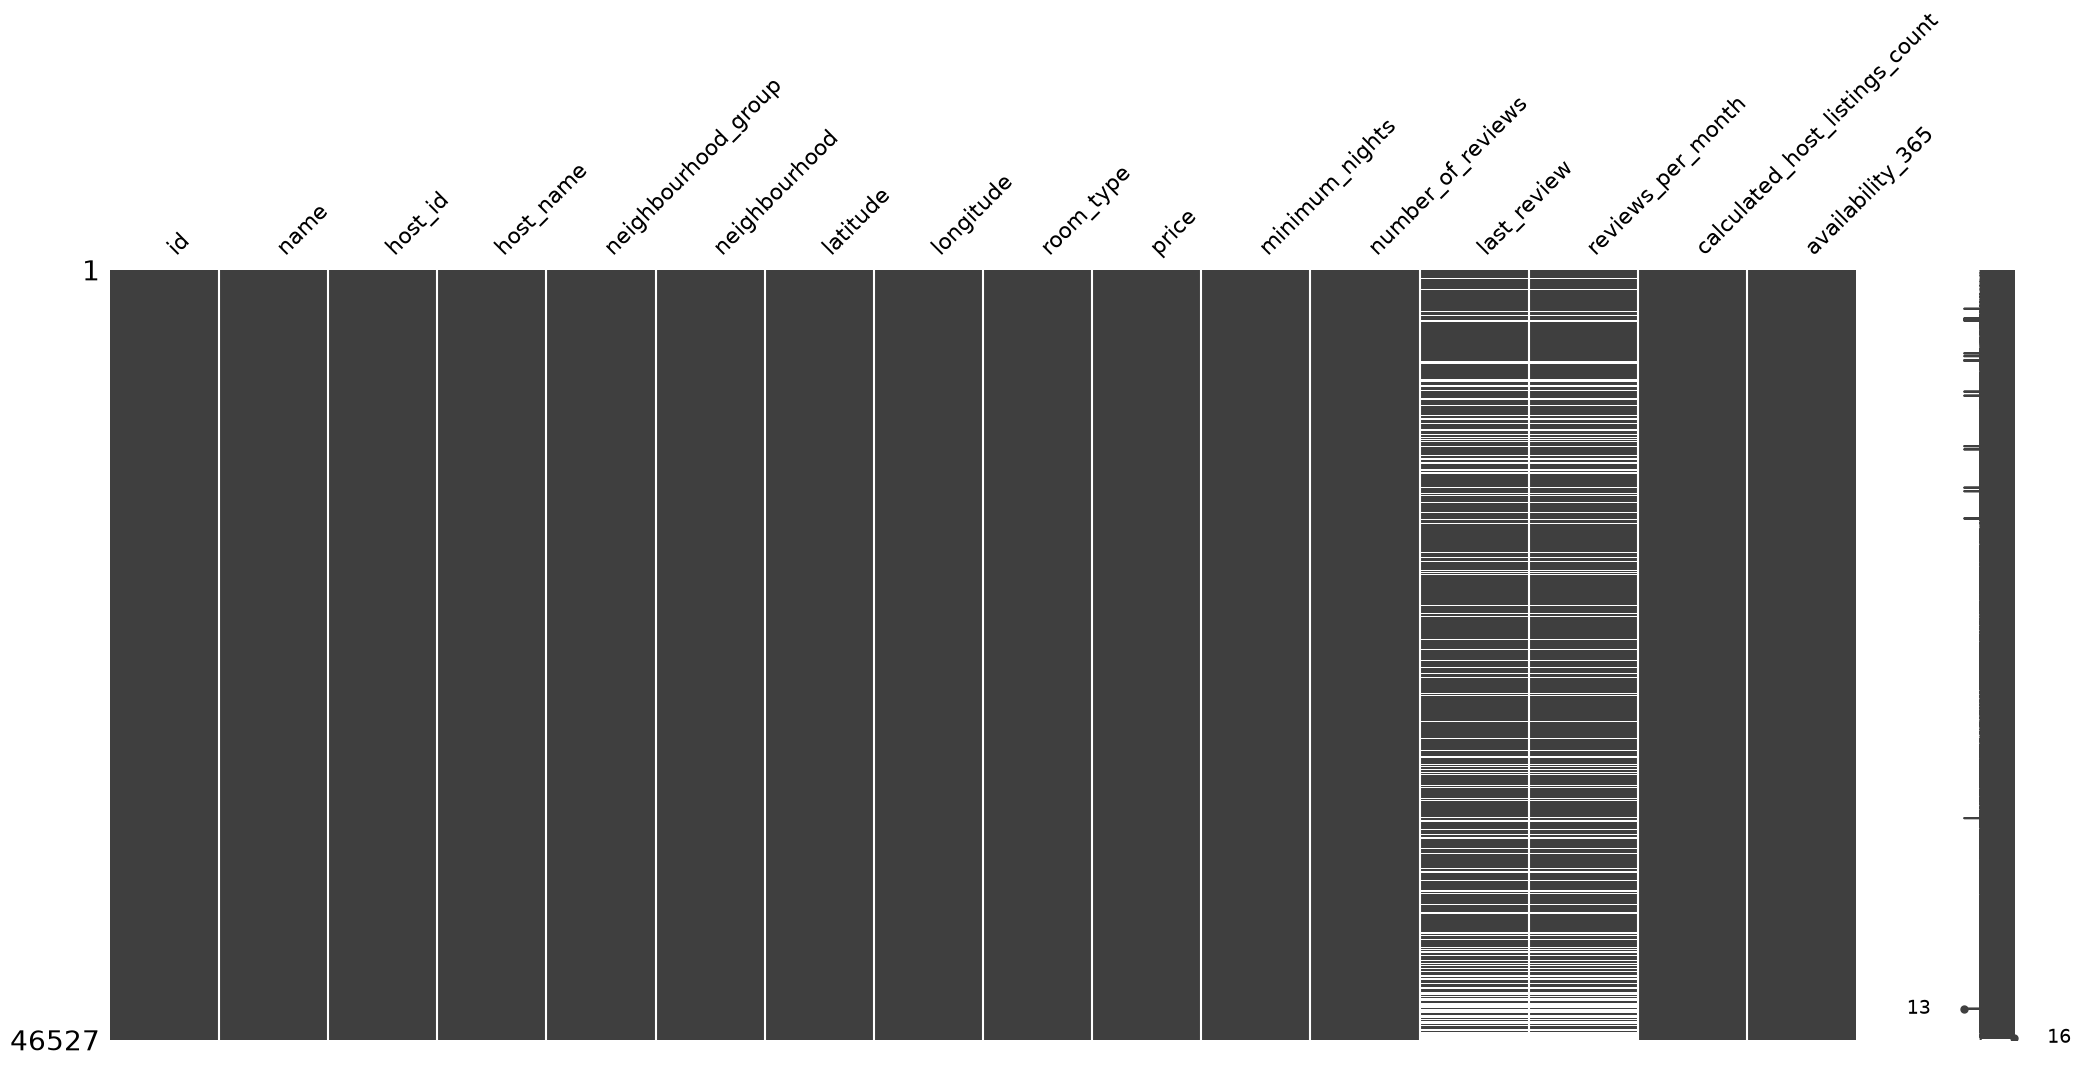

In [48]:
msno.matrix(df)  #Creates a visual output which shows where the DataFrame has missing values.

<Axes: >

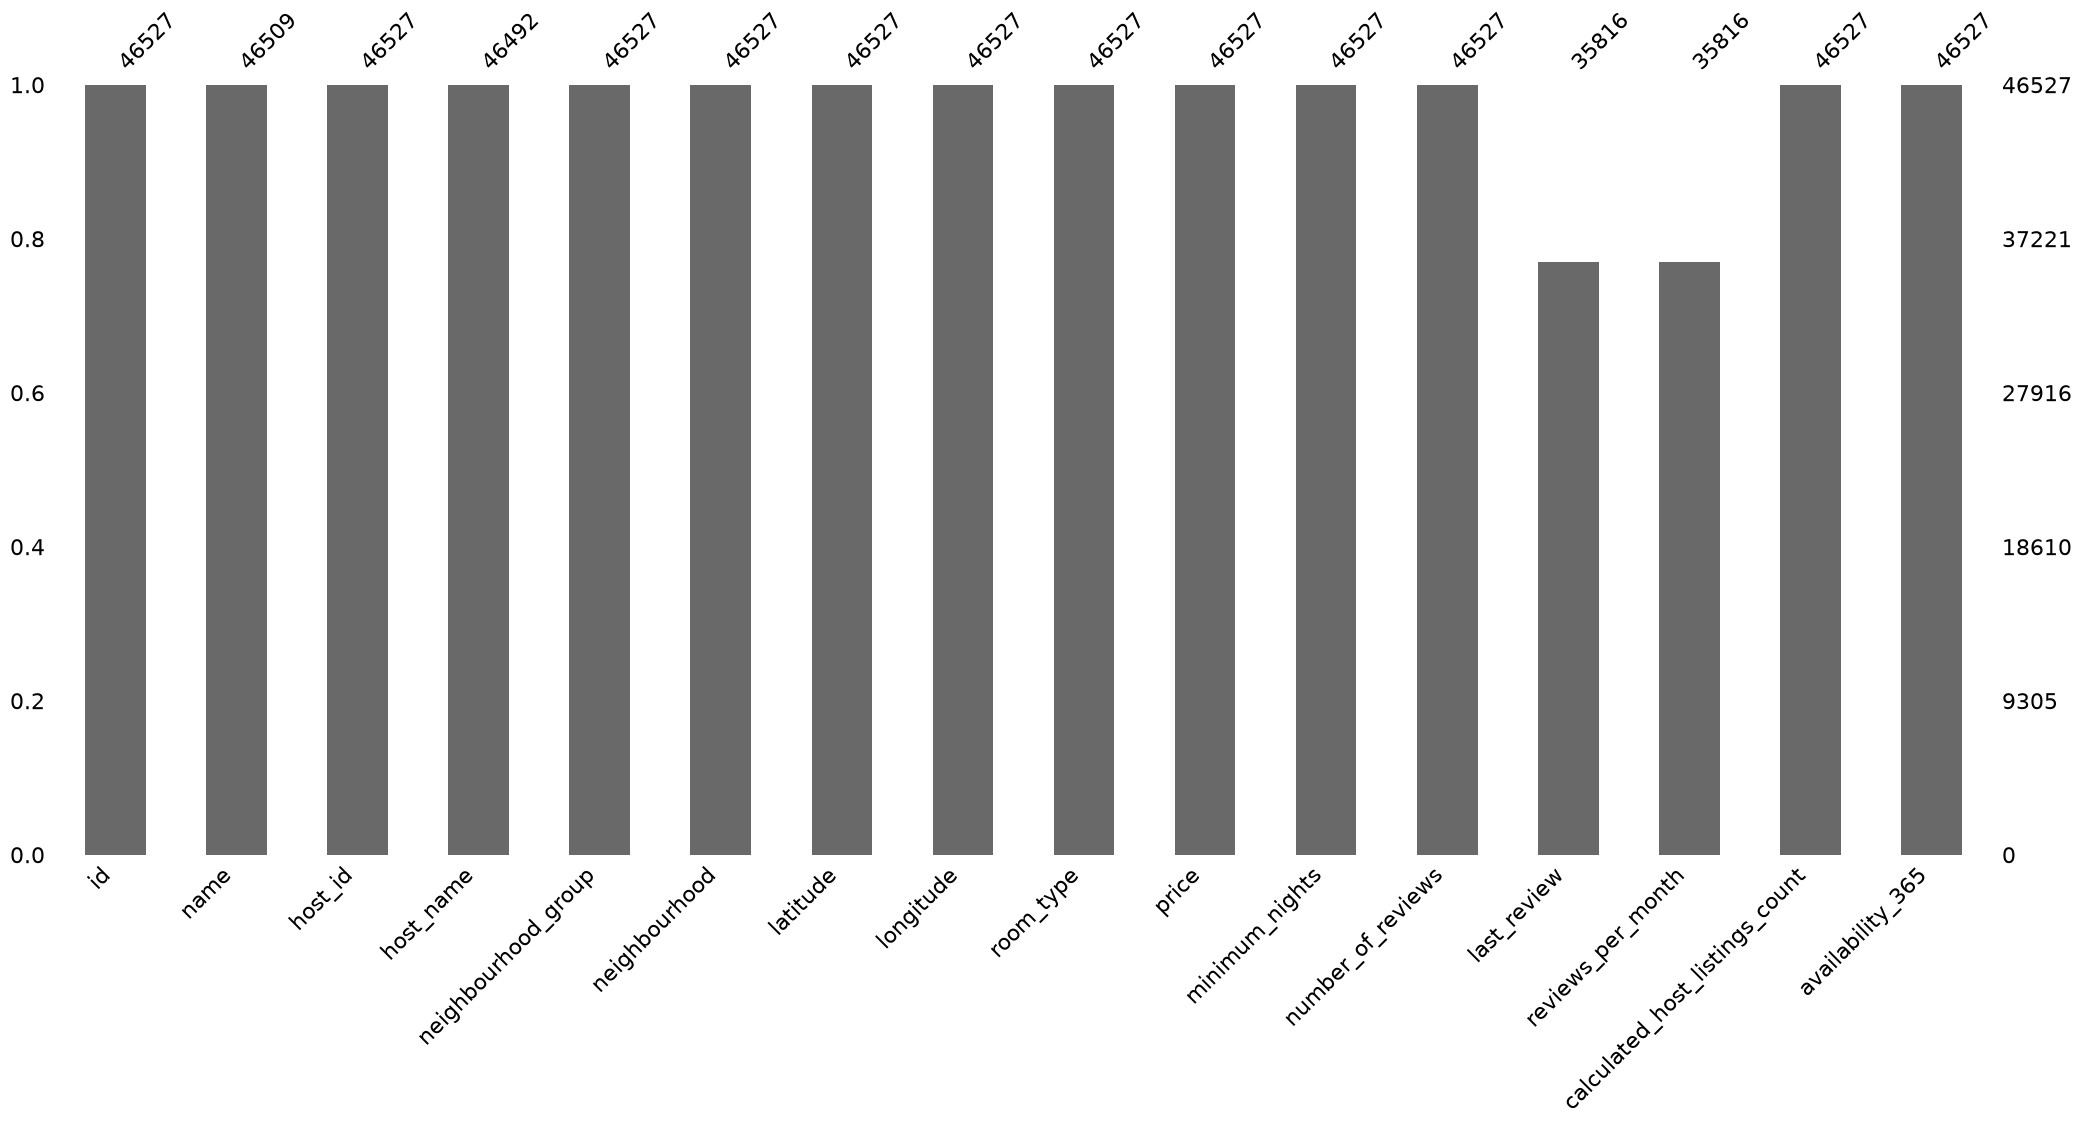

In [49]:
msno.bar(df)   # Outputs bar chart showing how many non-missing values each column has

### 3. (Medium) Use the grammys.csv data for the next section of questions.

1. Who was won Album of the Year in 2016?


2. Who won Best Rap Album in 2009?


3. How many awards was Kendrick Lamar nomiated for, and how many did he win...?

In [50]:
grammys = pd.read_csv("../data/grammys.csv")
grammys.head()

,year,category,nominee,workers,winner
0,1959,Album of the Year,The Music from Peter Gunn.,Henry Mancini,True
1,1959,Best Album Cover,Only the Lonely,Frank Sinatra (art director),True
2,1959,Best Arrangement,The Music From Peter Gunn,Henry Mancini (artist/arranger),True
3,1959,Best Classical Performance - Chamber Music (in...,Beethoven: Quartet 130,"The Hollywood String Quartet, Paul Shure (arti...",True
4,1959,Best Classical Performance - Instrumentalist (...,Segovia Golden Jubilee,Andrés Segovia,True


In [53]:
#1
 
album_2016 = grammys[
    (grammys["year"] == 2016) &
    (grammys["category"] == "Album of the Year") &
    (grammys["winner"] == True)
]

album_2016["nominee"]

5505    1989.
Name: nominee, dtype: str

### (Hard) Load the Game Logs for 2022 and add the column names using a dictionary.  
* [Link to the data page](https://www.retrosheet.org/gamelogs/)
* [Link to the column names](https://procatinator.com/)
* haha, gotta find them yourself!

### (Extra Hard) Download the files for the past 5 years into a new folder and add them all into one data frame using pandas, then save that new file.
* Try to not hard code in the file names. We want to do this programmatically because what if we want to add new/more file names in the future.